In [320]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

In [321]:
data_dir = "./Task-2"
image_path = os.path.join(data_dir, "AF1.jpg")

In [322]:
def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [323]:
def plot_images(images, titles=None, cols=3, figsize=(15, 10)):
    # Number of images
    num_images = len(images)
    
    # Calculate number of rows
    rows = math.ceil(num_images / cols)
    
    # Create the subplot grid
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.ravel()  # Flatten the 2D grid of axes to iterate over
    
    # Loop through each image and corresponding axis
    for i in range(rows * cols):
        if i < num_images:
            # Display image
            axes[i].imshow(images[i], cmap='gray' if len(images[i].shape) == 2 else None)
            
            # Add title if provided
            if titles:
                axes[i].set_title(titles[i], fontsize=12)
        else:
            # Hide any unused subplot
            axes[i].axis('off')
        
        # Remove axes for clarity
        axes[i].axis('off')
    
    # Adjust layout for better spacing
    plt.tight_layout()
    plt.show()

In [324]:
def remove_blinds(image):
    """
    Apply Gabor filter to detect horizontal structures in color images
    """

    kernel_size = 37

    # Create Gabor kernel for horizontal line detection
    gabor_kernel = cv2.getGaborKernel(
        ksize=(kernel_size, kernel_size),
        sigma=3.0,
        theta=0,
        lambd=17.5,
        gamma=0.5,
        psi=0,
        ktype=cv2.CV_32F
    )

    # Process each channel separately
    filtered_channels = []
    
    for channel in cv2.split(image):
        # Compute the Fourier Transform of the input channel
        dft_image = np.fft.fft2(channel)
        # Shift the zero frequency to the center
        dft_image_shifted = np.fft.fftshift(dft_image)

        # Compute the Fourier Transform of the Gabor filter
        padded_gabor_kernel = np.zeros_like(channel, dtype=np.float64)
        k_center = kernel_size // 2
        padded_gabor_kernel[:kernel_size, :kernel_size] = gabor_kernel
        padded_gabor_kernel = np.roll(padded_gabor_kernel, -k_center, axis=0)
        padded_gabor_kernel = np.roll(padded_gabor_kernel, -k_center, axis=1)
        dft_gabor_kernel = np.fft.fft2(padded_gabor_kernel)
        dft_gabor_kernel_shifted = np.fft.fftshift(dft_gabor_kernel)

        # Perform element-wise multiplication in the frequency domain
        filtered_dft = dft_image_shifted * dft_gabor_kernel_shifted

        # Inverse Fourier Transform to get the filtered image back in spatial domain
        filtered_dft_shifted_back = np.fft.ifftshift(filtered_dft)
        filtered_image = np.fft.ifft2(filtered_dft_shifted_back)
        filtered_image_real = np.real(filtered_image)  # Take only the real part

        # Normalize the filtered channel to the range [0, 255]
        filtered_channel_normalized = cv2.normalize(filtered_image_real, None, 0, 255, cv2.NORM_MINMAX)
        filtered_channel_normalized = filtered_channel_normalized.astype(np.uint8)

        # Denoise
        filtered_channel_normalized = cv2.fastNlMeansDenoising(filtered_channel_normalized)

        filtered_channels.append(filtered_channel_normalized)

    # Merge the processed channels back together
    return bgr_to_rgb(cv2.merge(filtered_channels))

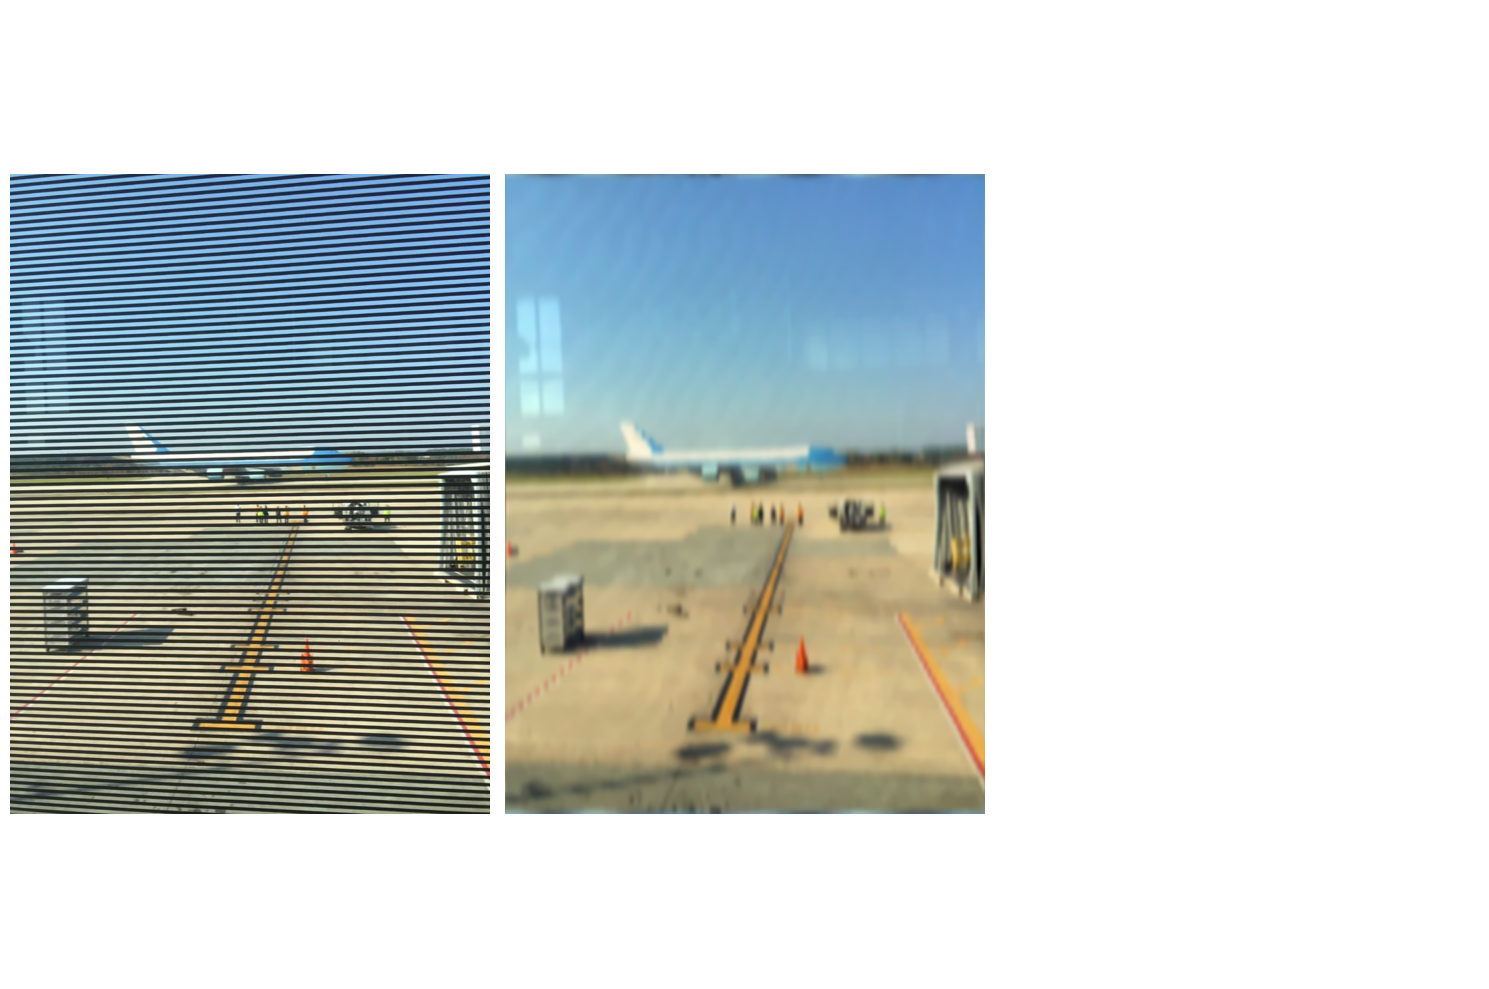

In [325]:
image = cv2.imread(image_path)

plot_images([bgr_to_rgb(image), remove_blinds(image)])
